In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Detectar a raiz do projeto automaticamente

In [4]:
caminho_atual = Path.cwd()

if caminho_atual.name == "notebooks":
    raiz_projeto = caminho_atual.parent
else:
    raiz_projeto = caminho_atual

pasta_dataset = raiz_projeto / "dataset" / "original" / "Dataset"
pasta_resultados = raiz_projeto / "resultados"

pasta_resultados.mkdir(exist_ok=True)

print("Raiz do projeto:", raiz_projeto)
print("Pasta do dataset:", pasta_dataset)
print("Pasta de resultados:", pasta_resultados)
print("Dataset existe?", pasta_dataset.exists())

Raiz do projeto: c:\Users\albet\processamento-de-imagens
Pasta do dataset: c:\Users\albet\processamento-de-imagens\dataset\original\Dataset
Pasta de resultados: c:\Users\albet\processamento-de-imagens\resultados
Dataset existe? True


Quantidsde de magens no dataset

In [5]:
imagens_raw = sorted(list(pasta_dataset.rglob("*_RAW.jpg")))

print(f"Total de imagens RAW encontradas: {len(imagens_raw)}")

for imagem in imagens_raw[:10]:
    print(imagem)

Total de imagens RAW encontradas: 2235
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1007599_RS_386_386RS289112_28920\1007599_RS_386_386RS289112_28920_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1007600_RS_386_386RS289112_28925\1007600_RS_386_386RS289112_28925_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1007607_RS_386_386RS289112_28960\1007607_RS_386_386RS289112_28960_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1007608_RS_386_386RS289112_28966\1007608_RS_386_386RS289112_28966_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1008367_RS_386_386RS289112_32760\1008367_RS_386_386RS289112_32760_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1008560_RS_386_386RS289112_33725\1008560_RS_386_386RS289112_33725_RAW.jpg
c:\Users\albet\processamento-de-imagens\dataset\original\Dataset\1014583_RS_386_386RS124739_29840\1014583_RS_386_386RS124739_29

Visualizar imagem original

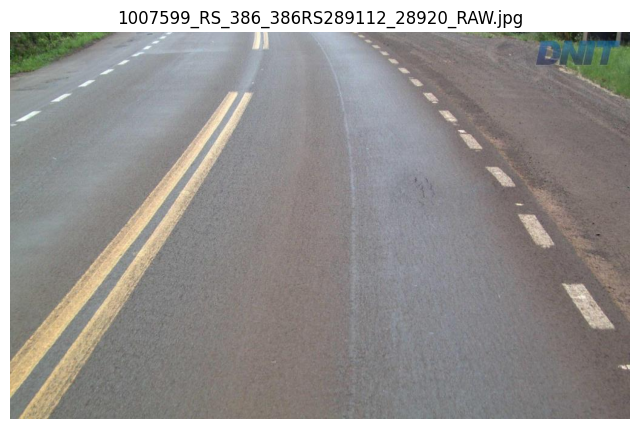

In [6]:
caminho_imagem = imagens_raw[0]

imagem = cv2.imread(str(caminho_imagem))
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(imagem_rgb)
plt.title(caminho_imagem.name)
plt.axis("off")
plt.show()

In [7]:
pasta_caso = caminho_imagem.parent

mascara_crack = list(pasta_caso.glob("*_CRACK.png"))
mascara_pothole = list(pasta_caso.glob("*_POTHOLE.png"))
mascara_lane = list(pasta_caso.glob("*_LANE.png"))

print("Imagem original:", caminho_imagem.name)
print("Máscara de rachadura:", mascara_crack[0].name if mascara_crack else "Não encontrada")
print("Máscara de buraco:", mascara_pothole[0].name if mascara_pothole else "Não encontrada")
print("Máscara da pista:", mascara_lane[0].name if mascara_lane else "Não encontrada")

Imagem original: 1007599_RS_386_386RS289112_28920_RAW.jpg
Máscara de rachadura: 1007599_RS_386_386RS289112_28920_CRACK.png
Máscara de buraco: 1007599_RS_386_386RS289112_28920_POTHOLE.png
Máscara da pista: 1007599_RS_386_386RS289112_28920_LANE.png


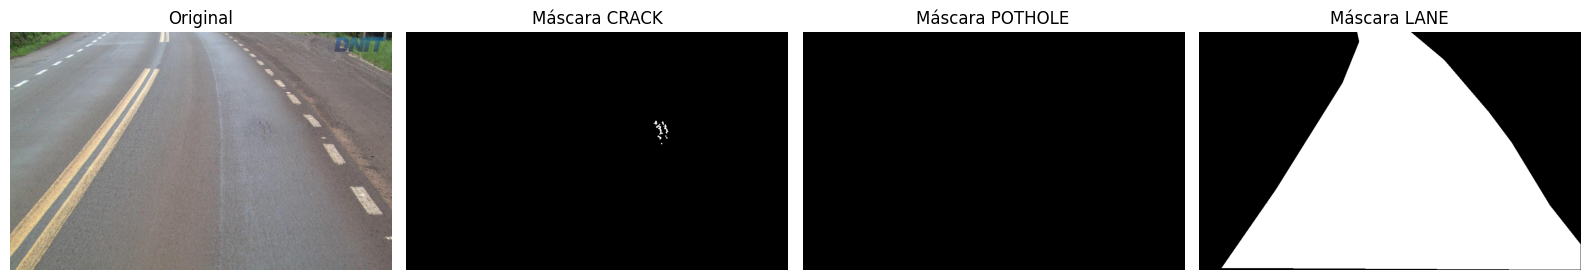

In [8]:
imagens_para_mostrar = []

# Original
original = cv2.imread(str(caminho_imagem))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
imagens_para_mostrar.append(("Original", original))

# Máscaras
if mascara_crack:
    crack = cv2.imread(str(mascara_crack[0]), cv2.IMREAD_GRAYSCALE)
    imagens_para_mostrar.append(("Máscara CRACK", crack))

if mascara_pothole:
    pothole = cv2.imread(str(mascara_pothole[0]), cv2.IMREAD_GRAYSCALE)
    imagens_para_mostrar.append(("Máscara POTHOLE", pothole))

if mascara_lane:
    lane = cv2.imread(str(mascara_lane[0]), cv2.IMREAD_GRAYSCALE)
    imagens_para_mostrar.append(("Máscara LANE", lane))

plt.figure(figsize=(16, 5))

for i, (titulo, img) in enumerate(imagens_para_mostrar):
    plt.subplot(1, len(imagens_para_mostrar), i + 1)
    
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
        
    plt.title(titulo)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def processar_imagem(caminho_imagem, limiar=100, area_minima=100):
    imagem = cv2.imread(str(caminho_imagem))

    if imagem is None:
        raise FileNotFoundError(f"Imagem não encontrada: {caminho_imagem}")

    imagem = cv2.resize(imagem, (512, 512))

    cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(cinza, (5, 5), 0)

    _, binaria = cv2.threshold(
        blur,
        limiar,
        255,
        cv2.THRESH_BINARY_INV
    )

    kernel = np.ones((3, 3), np.uint8)

    morfologia = cv2.morphologyEx(
        binaria,
        cv2.MORPH_OPEN,
        kernel
    )

    contornos, _ = cv2.findContours(
        morfologia,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    resultado = imagem.copy()

    quantidade_regioes = 0

    for contorno in contornos:
        area = cv2.contourArea(contorno)

        if area > area_minima:
            x, y, w, h = cv2.boundingRect(contorno)
            cv2.rectangle(resultado, (x, y), (x + w, y + h), (0, 0, 255), 2)
            quantidade_regioes += 1

    return {
        "original": imagem,
        "cinza": cinza,
        "blur": blur,
        "binaria": binaria,
        "morfologia": morfologia,
        "resultado": resultado,
        "quantidade_regioes": quantidade_regioes
    }

In [10]:
dados = processar_imagem(
    caminho_imagem=imagens_raw[0],
    limiar=100,
    area_minima=100
)

print("Regiões suspeitas detectadas:", dados["quantidade_regioes"])

Regiões suspeitas detectadas: 2


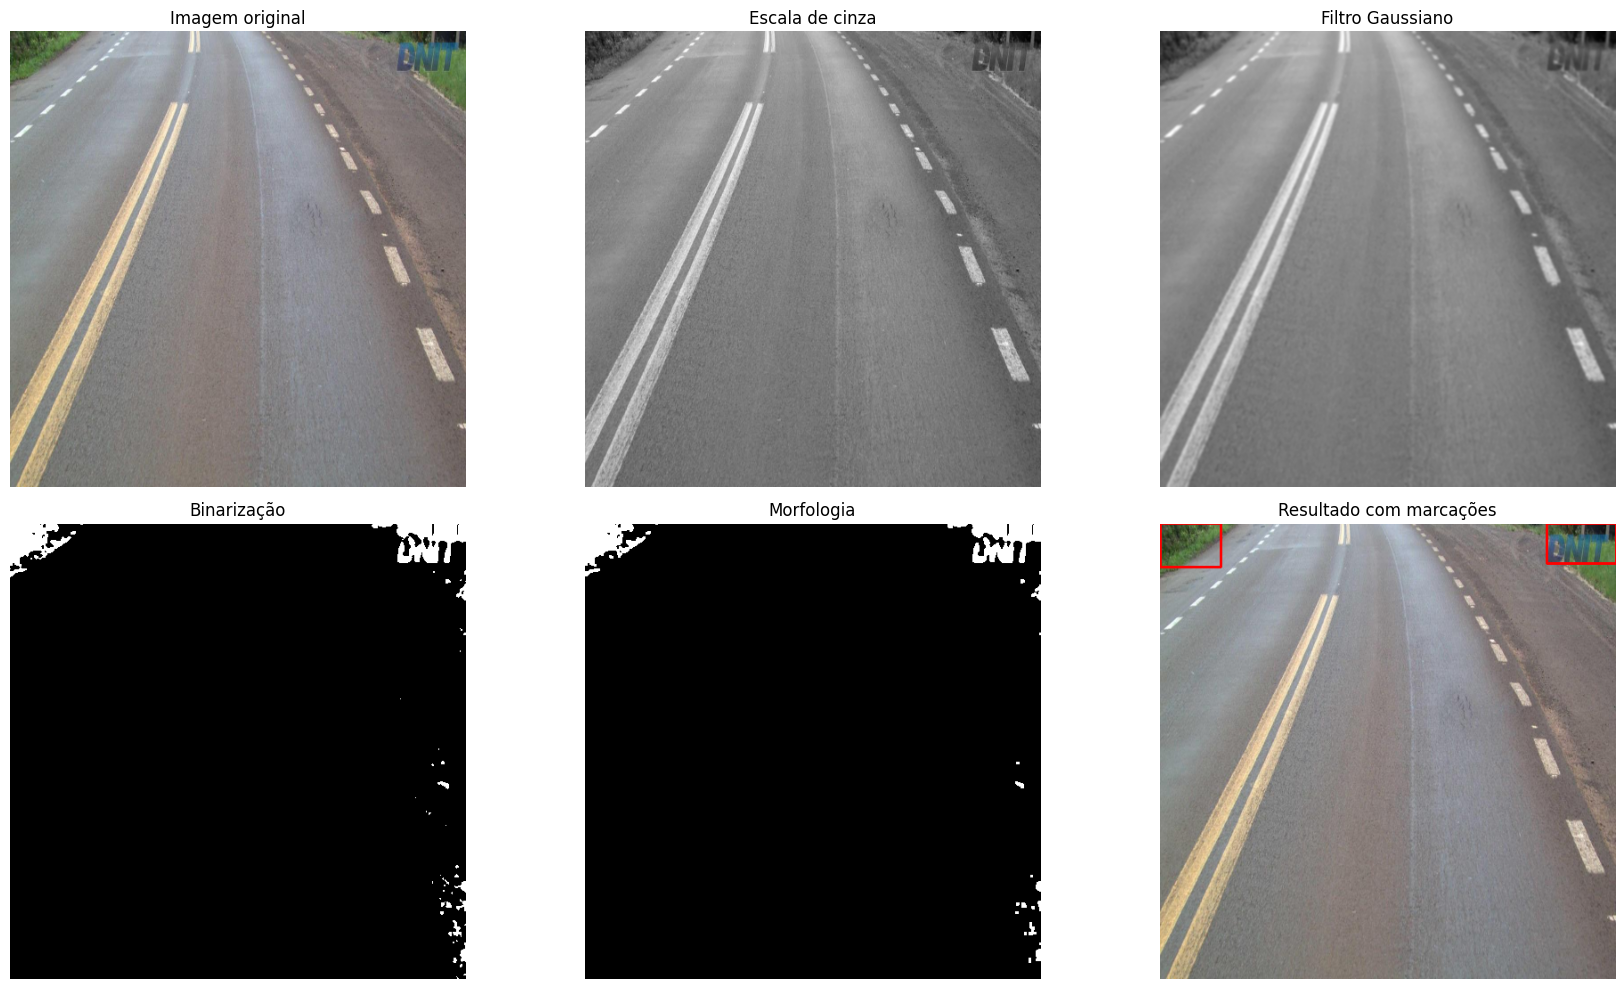

In [11]:
original_rgb = cv2.cvtColor(dados["original"], cv2.COLOR_BGR2RGB)
resultado_rgb = cv2.cvtColor(dados["resultado"], cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(dados["cinza"], cmap="gray")
plt.title("Escala de cinza")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dados["blur"], cmap="gray")
plt.title("Filtro Gaussiano")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(dados["binaria"], cmap="gray")
plt.title("Binarização")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(dados["morfologia"], cmap="gray")
plt.title("Morfologia")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(resultado_rgb)
plt.title("Resultado com marcações")
plt.axis("off")

plt.tight_layout()
plt.show()

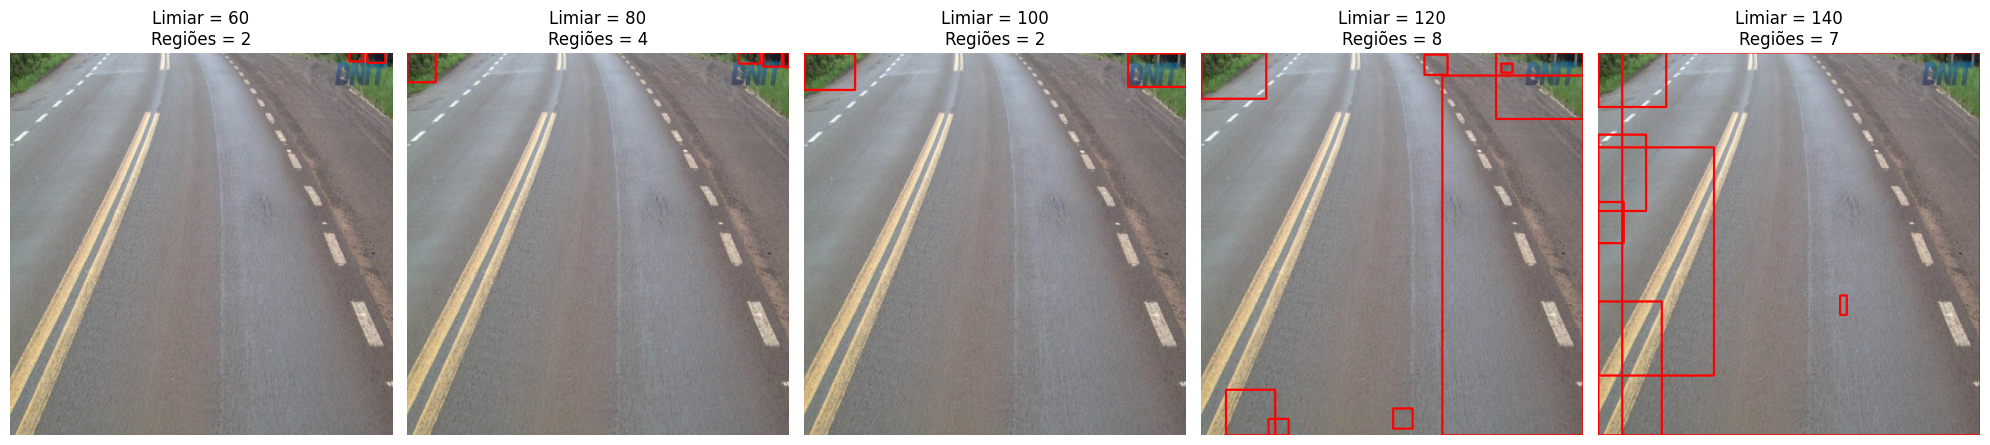

In [12]:
limiares = [60, 80, 100, 120, 140]

plt.figure(figsize=(20, 6))

for i, limiar in enumerate(limiares):
    dados_teste = processar_imagem(
        caminho_imagem=imagens_raw[0],
        limiar=limiar,
        area_minima=100
    )

    resultado_rgb = cv2.cvtColor(dados_teste["resultado"], cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(limiares), i + 1)
    plt.imshow(resultado_rgb)
    plt.title(f"Limiar = {limiar}\nRegiões = {dados_teste['quantidade_regioes']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

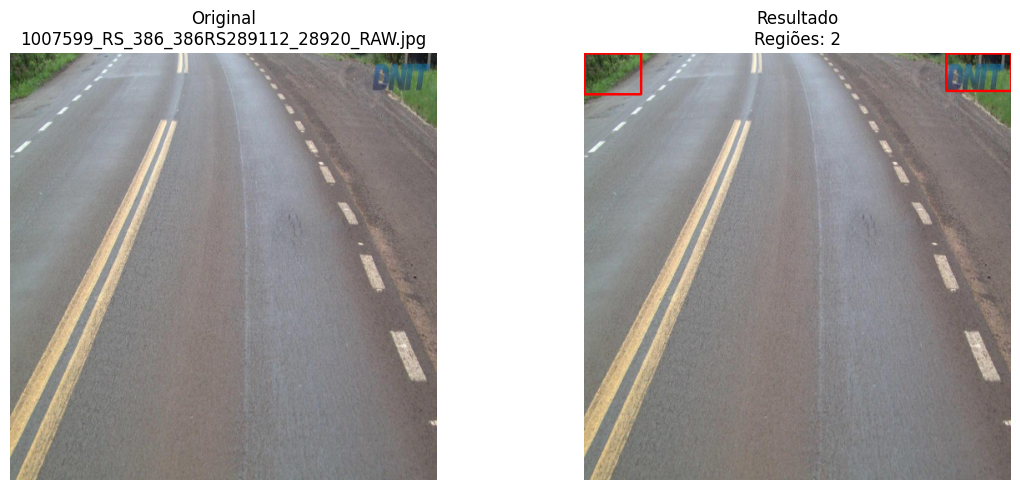

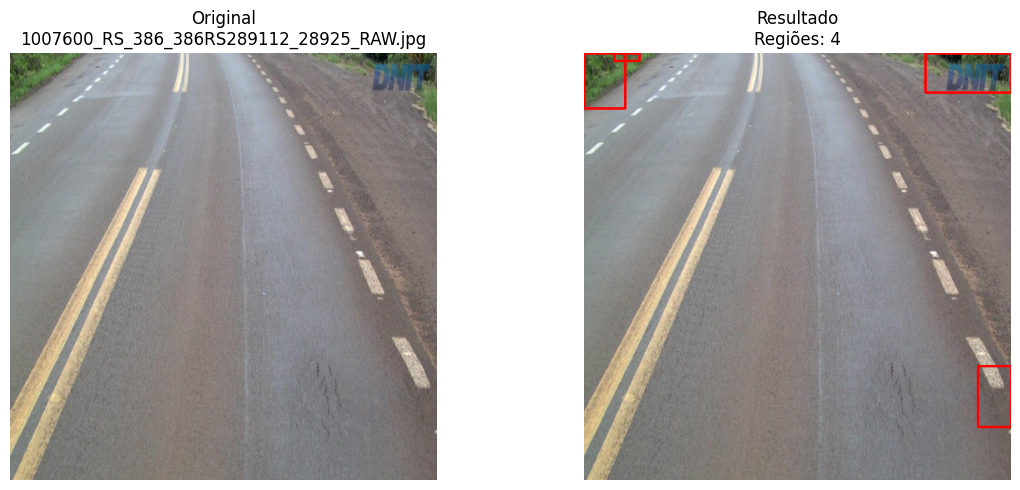

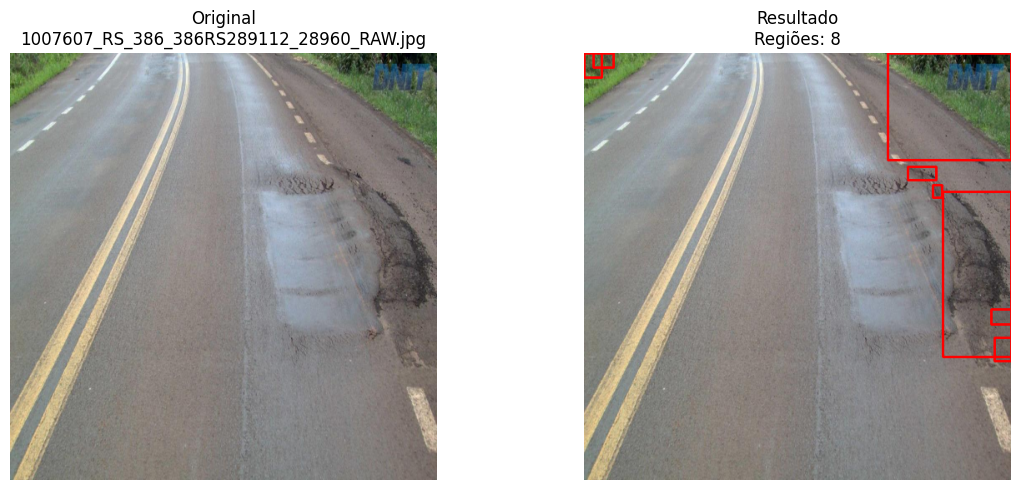

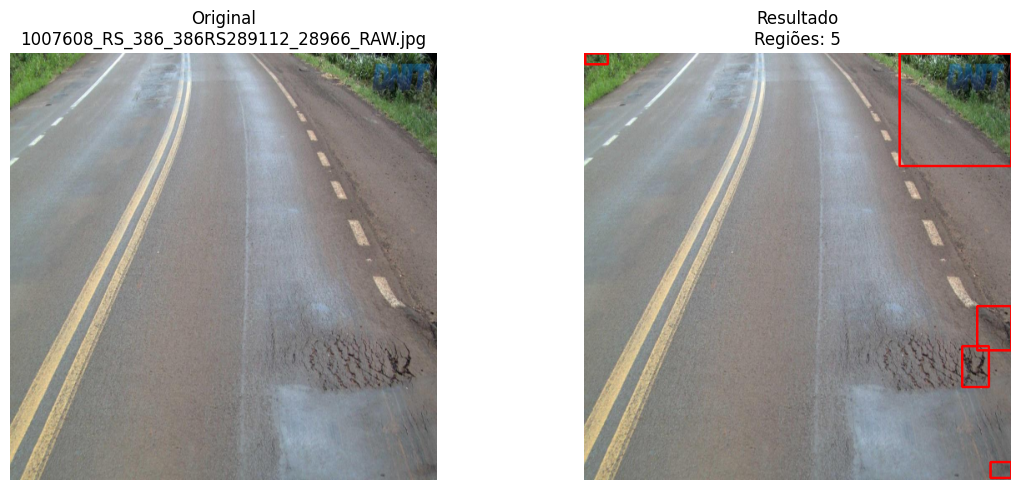

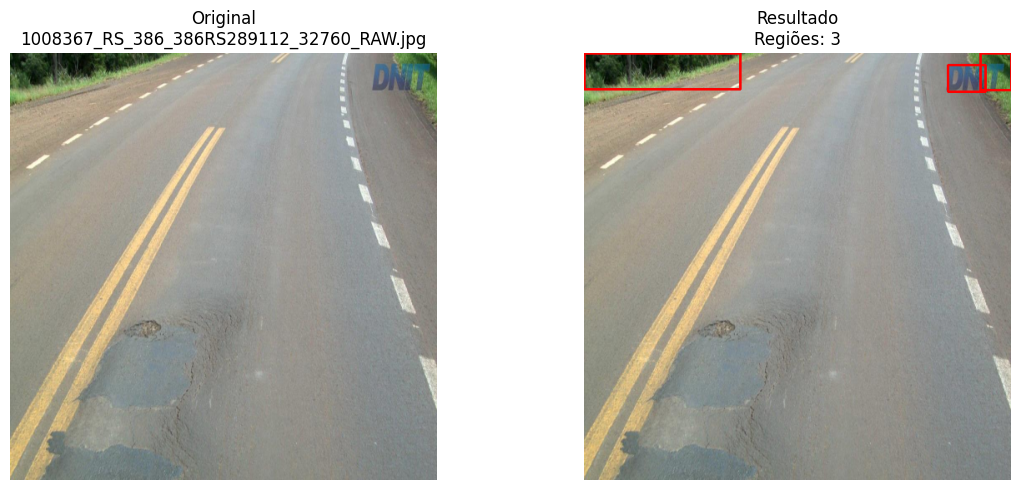

In [13]:
quantidade_teste = 5

for i, caminho in enumerate(imagens_raw[:quantidade_teste]):
    dados = processar_imagem(
        caminho_imagem=caminho,
        limiar=100,
        area_minima=100
    )

    original_rgb = cv2.cvtColor(dados["original"], cv2.COLOR_BGR2RGB)
    resultado_rgb = cv2.cvtColor(dados["resultado"], cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title(f"Original\n{caminho.name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(resultado_rgb)
    plt.title(f"Resultado\nRegiões: {dados['quantidade_regioes']}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()